<a href="https://colab.research.google.com/github/DzihniSafwaA1201/Data-Understanding-Data-Preprocessing/blob/main/Tugas_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import library

In [1]:
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

Load Dataset

In [2]:
df = pd.read_csv("House Price Prediction Dataset.csv")

df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


Dataset Audit
Identifikasi Variabel

In [3]:
print("Jumlah baris dan kolom:", df.shape)
print("\nNama kolom:")
print(df.columns)

Jumlah baris dan kolom: (2000, 10)

Nama kolom:
Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')


Analisis Tipe Data

In [4]:
print("\nTipe Data:")
print(df.dtypes)


Tipe Data:
Id            int64
Area          int64
Bedrooms      int64
Bathrooms     int64
Floors        int64
YearBuilt     int64
Location     object
Condition    object
Garage       object
Price         int64
dtype: object


Ringkasan Statistik

In [5]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


Distribusi Target (Price)

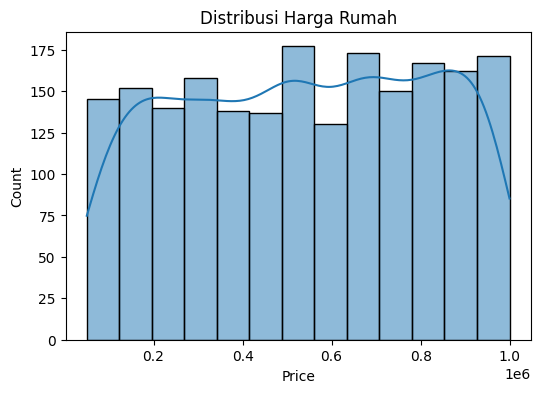

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df['Price'], kde=True)
plt.title("Distribusi Harga Rumah")
plt.show()

Missing Value Analysis

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print("Missing Values:")
print(missing)

Missing Values:
Series([], dtype: int64)


visualisasi

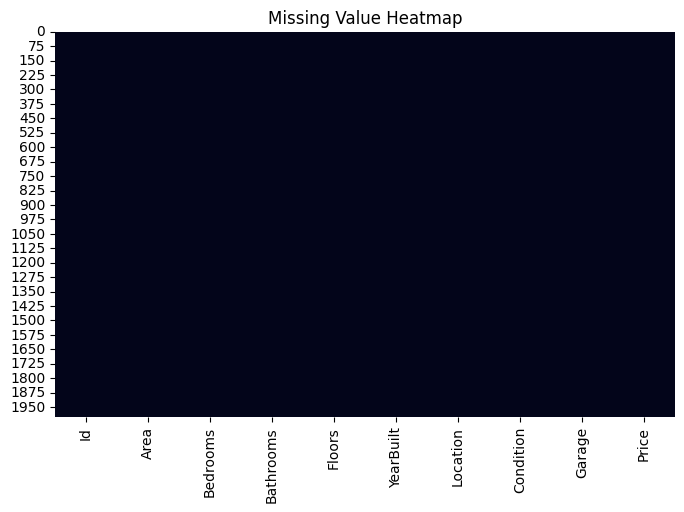

In [9]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

SPLIT FEATURE DAN TARGET
Target = price

In [12]:
X = df.drop("Price", axis=1)
y = df["Price"]

identifikasi tipe fitur

In [13]:
numeric_features = X.select_dtypes(include=['int64','float64']).columns

categorical_features = X.select_dtypes(include=['object']).columns

print("Numerical:", numeric_features)
print("Categorical:", categorical_features)

Numerical: Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt'], dtype='object')
Categorical: Index(['Location', 'Condition', 'Garage'], dtype='object')


DATA CLEANING + ENCODING + SCALING
Pipeline Numerical

In [14]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [15]:
#pipeline categorical

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

COLUMN TRANSFORMER

In [16]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

Split sebelum training model.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Fit hanya di training data supaya tidak terjadi data leakage.

In [18]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

hasil dataset

In [19]:
print("Train shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)

Train shape: (1600, 16)
Test shape: (400, 16)
